# Plot updates for Kern Feature Transformed and VF Transformed Dataset 04/12/2026 8:01:55 PM

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 

sns.set_context("paper", font_scale=1.4)

### Loss Curves

In [2]:
loss_curves = pd.read_csv("training_history.csv")
loss_curves.head()

,epoch,train_loss,test_loss
0,1,0.323082,0.078074
1,2,0.289232,0.082864
2,3,0.260500,0.105095
3,4,0.233094,0.139540
4,5,0.211933,0.180673


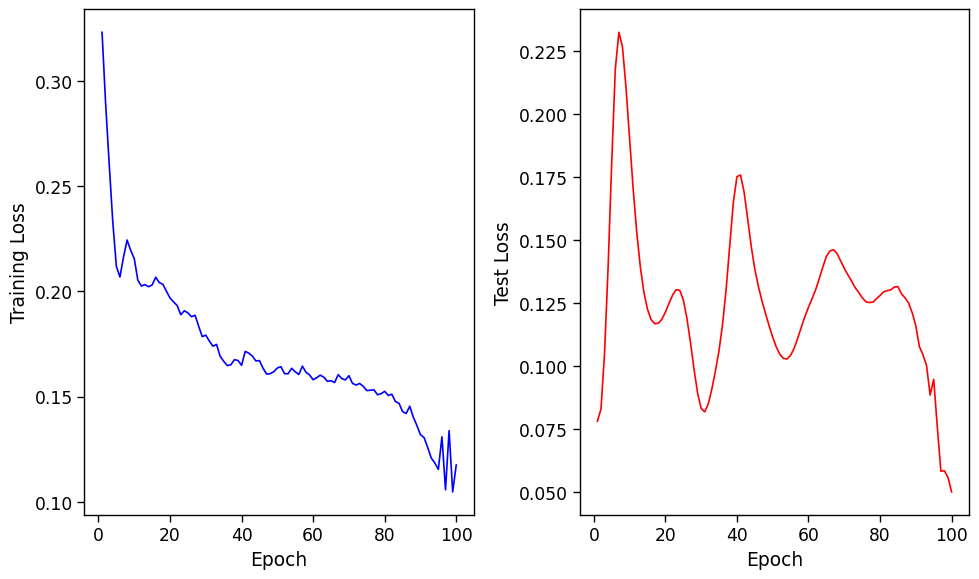

In [3]:
fig, ax = plt.subplots(figsize=(10,6), nrows= 1, ncols= 2)
sns.lineplot(data = loss_curves, x = "epoch", y = "train_loss", color="blue", ax=ax[0])
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training Loss")
sns.lineplot(data=loss_curves, x="epoch", y="test_loss", color="red", ax=ax[1])
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Test Loss")
plt.tight_layout()

### Prediction Curves

In [4]:
trainingset = pd.read_csv("true_vs_pred_train.csv")
testset = pd.read_csv("true_vs_pred_test.csv")
trainingset.tail()
shift_val = trainingset["sample_index"].to_numpy()[-1]

In [5]:
testset["sample_index"] = testset["sample_index"] + shift_val + 1
testset.tail()
final_val = testset["sample_index"].to_numpy()[-1]

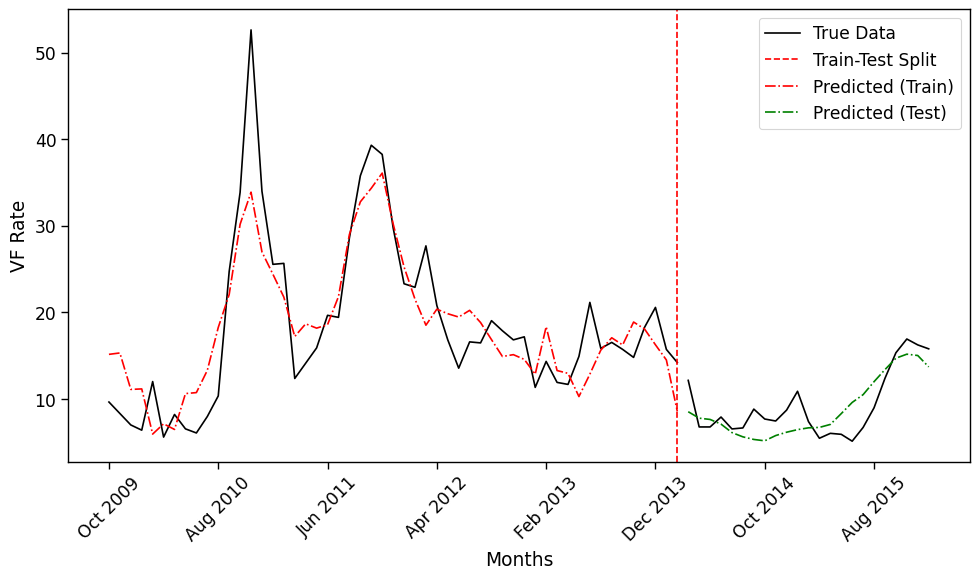

In [6]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=trainingset, x="sample_index", y="true_train", color="black", label="True Data")
ax.axvline(x=shift_val, color='red', linestyle='--', label="Train-Test Split")
sns.lineplot(data=testset, x="sample_index", y="true_test", color="black", label="_truedata")
sns.lineplot(data=trainingset, x="sample_index", y="pred_train", linestyle="-.", color='red', label="Predicted (Train)")
sns.lineplot(data=testset, x="sample_index", y="pred_test", linestyle="-.", color="green", label="Predicted (Test)")
plt.legend(loc="upper right")
# 1. Create the date range to match your 75 samples
dates = pd.date_range(start='2009-10-01', periods=75, freq='MS')


# 2. Select every 10th index
tick_indices = list(range(0, 75, 10))

# 3. Format the labels (e.g., 'Oct 2009', 'Aug 2010', etc.)
tick_labels = [dates[i].strftime('%b %Y') for i in tick_indices]

# 4. Apply to your plot
plt.xticks(tick_indices, tick_labels, rotation=45)
ax.set_xlabel("Months")
ax.set_ylabel("VF Rate")
plt.tight_layout()

### PFI Plots

In [7]:
pfi_data = pd.read_csv("pfi_importance.csv")
pfi_data

,Feature,Importance,window_size
0,PRECIP,-0.001688,1
1,WIND_EventCount,0.430526,9
2,WIND_AvgMPH,0.072239,1
3,WIND_RunMiles,1.448410,11
4,AQI_PM25,0.009288,2
5,AQI_PM10,-0.011670,1
6,EARTHQUAKE_Total,0.000898,1
7,YJ_PESTICIDE_Total,0.094587,1
8,log1p_RODENTICIDE_Total,0.122162,1
9,Avg_Monthly_DSCI,0.839521,10


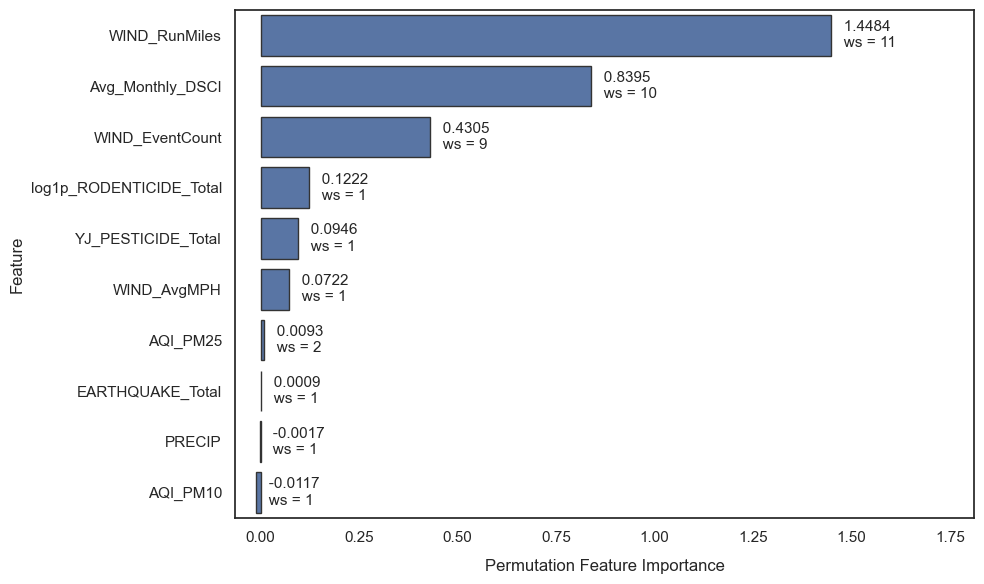

In [8]:
# 1. Slice for top 5
ranked_features = pfi_data.sort_values(by="Importance", ascending=False)

# 2. Setup Plot
sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Create Barplot
# We use a muted color and thin edges for a professional look
bars = sns.barplot(
    x="Importance", 
    y="Feature", 
    data=ranked_features, 
    color="#4C72B0",
    edgecolor=".2"
)

# 4. Annotate values to the right of the bars
for i, (index, row) in enumerate(ranked_features.iterrows()):
    imp = row['Importance']
    ws = int(row['window_size'])
    
    # Format the string: Importance value and Window Size abbreviation
    label = f"   {imp:.4f}\n   ws = {ws}"
    
    # Place text at the end of each bar
    ax.text(
        x = imp,            # Start text at the end of the bar
        y = i,              # Vertical center of the bar
        s = label,          # The string to print
        va = 'center',      # Vertical alignment
        ha = 'left',        # Horizontal alignment (starts to the right of x)
        fontsize = 11,
        fontweight = 'medium'
    )

# 5. Final Polish for Publication
ax.set_xlabel("Permutation Feature Importance", fontsize=12, labelpad=10)
ax.set_ylabel("Feature") 
ax.set_xlim(ranked_features['Importance'].min()*1.25 -.05 , ranked_features['Importance'].max() * 1.25) # Add padding for labels

plt.tight_layout()
plt.show()

In [9]:
# Compare all Kern RMSE values
kern_no_xforms = pd.read_csv("../kern_Rat_Drought_baseline_2026-04-12_16-21-09_Winner/true_vs_pred_test.csv")
kern_no_xforms.head()

,sample_index,true_test,pred_test
0,0,7.902205,13.587598
1,1,6.527908,11.968717
2,2,6.642433,10.212716
3,3,8.818402,8.683843
4,4,7.673155,8.587066


In [10]:
# Compare all Kern RMSE values
kern_featandtarget_xforms = pd.read_csv("../kern_Rat_Drought_feattransformed_vfrate_2026-04-12_20-01-55/true_vs_pred_test.csv")
kern_featandtarget_xforms.head()

,sample_index,true_test,pred_test
0,0,2.160233,2.334339
1,1,2.133469,2.371211
2,2,2.272526,2.240877
3,3,2.474843,2.081649
4,4,2.125938,2.045008


In [11]:
rmse_func = lambda x: np.sqrt(np.mean((x["pred_test"] - x["true_test"]))**2)

featxform_rmse = rmse_func(testset)
noxform_rmse = rmse_func(kern_no_xforms)
allxforms_rmse = rmse_func(kern_featandtarget_xforms)
print(f"No Transforms RMSE: {noxform_rmse:.3f}\nFeature Transforms RMSE: {featxform_rmse:.3f}\nAll Transforms RMSE: {allxforms_rmse:.3f}")


No Transforms RMSE: 0.364
Feature Transforms RMSE: 0.355
All Transforms RMSE: 0.061


RMSE unxformed: 2.0960652555817783


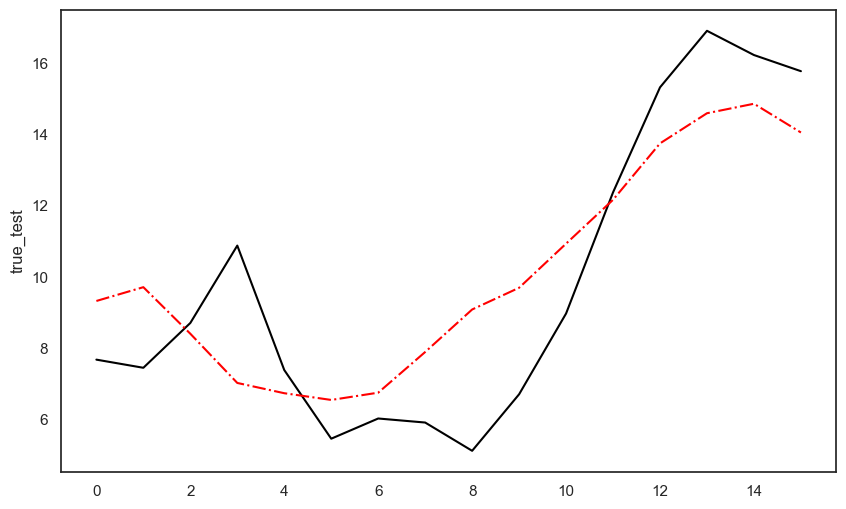

In [13]:
# plotting the log1p re-transformed predictions
unxformed_trues = np.exp(kern_featandtarget_xforms["true_test"]) - 1
unxformed_preds = np.exp(kern_featandtarget_xforms["pred_test"]) - 1
plotticks = np.arange(0, len(unxformed_trues), 1)

plt.figure(figsize=(10,6))
sns.lineplot(x=plotticks, y=unxformed_trues, color="black")
sns.lineplot(x=plotticks, y=unxformed_preds, color="red", linestyle="-.")
print(f"RMSE unxformed: {np.sqrt(np.mean((unxformed_preds - unxformed_trues)**2))}")